# GNN Model Implementation
> **Data Requirement:** This model requires `Data Files/negative_ProjectFinal_filtered_score0.1.csv`. 
> If you haven't generated it using the `SequenceIntegration` notebook, please download it [HERE](https://drive.google.com/file/d/1Aaw5wcOaLjBBvab3sXhod25xtk9jmJUp/view?usp=drive_link).

In [ ]:
%pip install Bio

  Using cached bio-1.8.1-py3-none-any.whl.metadata (5.7 kB)
  Using cached gprofiler_official-1.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
Using cached bio-1.8.1-py3-none-any.whl (321 kB)
Using cached gprofiler_official-1.0.0-py3-none-any.whl (9.3 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)

   -------------------------------- ------- 4/5 [Bio]
   ---------------------------------------- 5/5 [Bio]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Histograms**
To visualize the positive and negative datasets.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
positive_path = r"Data Files\positive_ProjectFinal.csv"
negative_path = r"Data Files\negative_ProjectFinal_filtered_score0.1.csv"

# Loading CSVs
pos_df = pd.read_csv(positive_path)
neg_df = pd.read_csv(negative_path)

# Converting Score to numeric values
pos_df["Score"] = pd.to_numeric(pos_df["Score"], errors="coerce")
neg_df["Score"] = pd.to_numeric(neg_df["Score"], errors="coerce")

# Dropping missing or invalid scores
pos_scores = pos_df["Score"].dropna()
neg_scores = neg_df["Score"].dropna()

# Histogram 1: Positive Dataset

plt.figure(figsize=(8, 5))
plt.hist(pos_scores, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title("Histogram of Score Values (Positive Dataset)", fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Histogram 2: Negative Dataset

plt.figure(figsize=(8, 5))
plt.hist(neg_scores, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title("Histogram of Score Values (Negative Dataset)", fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

The **GNN** model

Device: cuda

Embedding all proteins...

===== FOLD 1 =====
Epoch 0 | Loss: 0.7119
Epoch 1 | Loss: 0.7749
Epoch 2 | Loss: 0.6550
Epoch 3 | Loss: 0.6525
Epoch 4 | Loss: 0.5937
Epoch 5 | Loss: 0.5635
Epoch 6 | Loss: 0.5221
Epoch 7 | Loss: 0.4475

===== FOLD 2 =====
Epoch 0 | Loss: 0.6987
Epoch 1 | Loss: 0.6823
Epoch 2 | Loss: 0.6524
Epoch 3 | Loss: 0.5909
Epoch 4 | Loss: 0.5357
Epoch 5 | Loss: 0.4771
Epoch 6 | Loss: 0.4099
Epoch 7 | Loss: 0.3465

===== FOLD 3 =====
Epoch 0 | Loss: 0.6971
Epoch 1 | Loss: 0.7091
Epoch 2 | Loss: 0.6483
Epoch 3 | Loss: 0.6156
Epoch 4 | Loss: 0.5348
Epoch 5 | Loss: 0.5079
Epoch 6 | Loss: 0.4373
Epoch 7 | Loss: 0.3676

===== FOLD 4 =====
Epoch 0 | Loss: 0.7025
Epoch 1 | Loss: 0.7257
Epoch 2 | Loss: 0.6411
Epoch 3 | Loss: 0.6272
Epoch 4 | Loss: 0.5526
Epoch 5 | Loss: 0.5166
Epoch 6 | Loss: 0.4582
Epoch 7 | Loss: 0.3820

===== FOLD 5 =====
Epoch 0 | Loss: 0.6985
Epoch 1 | Loss: 0.7611
Epoch 2 | Loss: 0.6439
Epoch 3 | Loss: 0.6569
Epoch 4 | Loss: 0.5955
Epoch 5 |

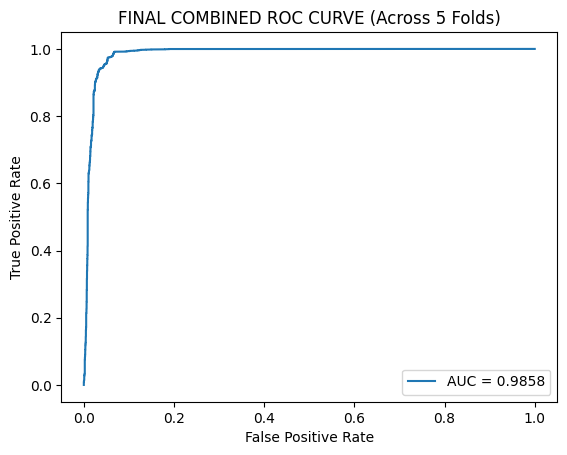

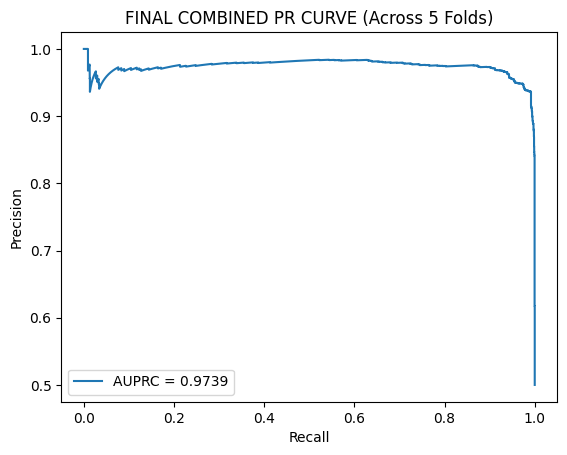


===== FINAL RESULTS (AVERAGED ACROSS 5 FOLDS) =====
Accuracy:   0.9561
Precision:  0.9500
Recall:     0.9641
F1 Score:   0.9562
AUC-ROC:    0.9882
AUPRC:      0.9747
Total nodes: 3311
Human nodes: 3299
Viral nodes: 12
Total positive edges: 3261
Total negative edges: 3261
Common edges: 48
Edges only in positive set: 3213
Edges only in negative set: 3213


In [ ]:
# =================================
# 1. Importing necessary libraries
# =================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# 2. Loading ProtBERT model
# ===============================
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
protbert = BertModel.from_pretrained("Rostlab/prot_bert").to(device)
protbert.eval()

MAX_LEN = 512

def embed_protein(seq):
    """Chunk-safe ProtBERT embedding"""
    seq = seq.replace(" ", "").upper()
    chunks = [seq[i:i+MAX_LEN] for i in range(0, len(seq), MAX_LEN)]

    reps = []
    for ch in chunks:
        spaced = " ".join(list(ch))
        inputs = tokenizer(spaced, return_tensors="pt").to(device)
        with torch.no_grad():
            out = protbert(**inputs)
        reps.append(out.last_hidden_state[:,0,:])   # CLS token

    rep = torch.mean(torch.stack(reps), dim=0)      # Mean pool chunks
    return rep.squeeze(0)

# ===============================
# 3. Loading data files
# ===============================
pos_df = pd.read_csv(r"Data Files\positive_ProjectFinal.csv")
neg_df = pd.read_csv(r"Data Files\negative_ProjectFinal_filtered_score0.1.csv")

# One negative set
neg_df = neg_df.sample(n=len(pos_df), random_state=42).reset_index(drop=True)

#neg_df.to_csv("NegativeSample1.csv", index=False)

df = pd.concat([pos_df, neg_df], ignore_index=True)
df["Label"] = [1]*len(pos_df) + [0]*len(neg_df)

# ===============================
# 4. Building node dictionary
# ===============================
all_humans = df["Human"].unique().tolist()
all_viruses = df["SARS-CoV2"].unique().tolist()

human_to_id = {h: i for i, h in enumerate(all_humans)}
virus_to_id = {v: i+len(all_humans) for i, v in enumerate(all_viruses)}

num_nodes = len(all_humans) + len(all_viruses)

# ===============================
# 5. Emdedding all proteins
# ===============================
print("\nEmbedding all proteins...")

node_features = torch.zeros((num_nodes, 1024), device=device)

for h in all_humans:
    node_features[human_to_id[h]] = embed_protein(
        df[df["Human"] == h]["Human_Sequence"].iloc[0]
    )

for v in all_viruses:
    node_features[virus_to_id[v]] = embed_protein(
        df[df["SARS-CoV2"] == v]["SARS-CoV2_Sequence"].iloc[0]
    )

# ===============================
# 6. Building the graph edges
# ===============================
edge_list = []

for i, row in df.iterrows():
    u = human_to_id[row["Human"]]
    v = virus_to_id[row["SARS-CoV2"]]
    edge_list.append([u, v])
    edge_list.append([v, u])   # This is a undirected graph

edge_index = torch.tensor(edge_list, dtype=torch.long).t().to(device)

# Edge pairs which will be used for GNN classification
edge_pairs = torch.tensor([
    [human_to_id[row["Human"]], virus_to_id[row["SARS-CoV2"]]]
    for _, row in df.iterrows()
], dtype=torch.long).to(device)

labels = torch.tensor(df["Label"].values).long().to(device)

# ===============================
# 7. The GCN model
# ===============================
class GCN(nn.Module):
    def __init__(self, in_dim=1024, hid=512, out_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid)
        self.conv2 = GCNConv(hid, out_dim)
        self.relu = nn.ReLU()

        self.edge_mlp = nn.Sequential(
            nn.Linear(out_dim*2, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, edge_index, edge_pairs):
        x = self.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)

        u = x[edge_pairs[:,0]]
        v = x[edge_pairs[:,1]]
        uv = torch.cat([u, v], dim=1)

        return self.edge_mlp(uv).squeeze()

# ================================
# 8. The K-fold training with k=5
# ================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

final_metrics = []
all_probs = []
all_true = []

for fold, (train_i, test_i) in enumerate(kf.split(edge_pairs)):
    print(f"\n===== FOLD {fold+1} =====")

    model = GCN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()

    train_idx = torch.tensor(train_i).to(device)
    test_idx = torch.tensor(test_i).to(device)

    # - Train -
    for epoch in range(8):
        model.train()
        opt.zero_grad()

        out = model(node_features, edge_index, edge_pairs[train_idx])
        loss = loss_fn(out, labels[train_idx].float())
        loss.backward()
        opt.step()

        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    # - Test -
    model.eval()
    with torch.no_grad():
        probs = model(node_features, edge_index, edge_pairs[test_idx]).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        true = labels[test_idx].cpu().numpy()

        # Saving for combined curves
        all_probs.extend(probs)
        all_true.extend(true)

        # Folding metrics
        acc = accuracy_score(true, preds)
        prec = precision_score(true, preds)
        rec = recall_score(true, preds)
        f1 = f1_score(true, preds)
        auc_val = roc_auc_score(true, probs)

        p_vals, r_vals, _ = precision_recall_curve(true, probs)
        pr_auc = auc(r_vals, p_vals)

        final_metrics.append([acc, prec, rec, f1, auc_val, pr_auc])

# ===========================================
# 9. Combined ROC & PR curves for all 5 folds
# ===========================================
all_probs = np.array(all_probs)
all_true = np.array(all_true)

# - Final combined ROC -
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc_val = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FINAL COMBINED ROC CURVE (Across 5 Folds)")
plt.legend()
plt.show()

# - Final combined PR -
precision_vals, recall_vals, _ = precision_recall_curve(all_true, all_probs)
pr_auc_val = auc(recall_vals, precision_vals)

plt.plot(recall_vals, precision_vals, label=f"AUPRC = {pr_auc_val:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("FINAL COMBINED PR CURVE (Across 5 Folds)")
plt.legend()
plt.show()

# ===============================================
# 10. Final mmetrices averaged across all 5 folds
# ===============================================
m = np.array(final_metrics)

print("\n===== FINAL RESULTS (AVERAGED ACROSS 5 FOLDS) =====")
print(f"Accuracy:   {m[:,0].mean():.4f}")
print(f"Precision:  {m[:,1].mean():.4f}")
print(f"Recall:     {m[:,2].mean():.4f}")
print(f"F1 Score:   {m[:,3].mean():.4f}")
print(f"AUC-ROC:    {m[:,4].mean():.4f}")
print(f"AUPRC:      {m[:,5].mean():.4f}")

